# Benchmark de Modelos para Deteccion de Fraude

Este notebook construye un flujo de modelado **sin leakage** sobre `credit_card_transactions_model_input.csv`, con foco en:

1. EDA de **variables engineered** (prefijos `A*`, `T*`, `L*`) para complementar el EDA original.
2. Pipeline de preprocesamiento inteligente para datos mixtos (numericos + categoricos).
3. Entrenamiento y comparacion de modelos benchmark con **SMOTE** y **cross-validation**.
4. Evaluacion robusta para alto desbalance: metricas clave, matrices de confusion, ROC, PR y Lift.

Modelos evaluados:
- XGBoost
- RandomForest
- LightGBM
- CatBoost

## 1. Setup y carga de datos

Este notebook evita repetir el EDA inicial de `EDA.ipynb` y se concentra en el comportamiento de variables derivadas por feature engineering.

In [6]:
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COL = "is_fraud"
DATA_PATH = Path("credit_card_transactions_model_input.csv")
ENGINEERED_PATTERN = re.compile(r"^[ATL]\\d+_")

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)

print("Setup listo")
print(f"Dataset objetivo: {DATA_PATH.resolve()}")

Setup listo
Dataset objetivo: C:\Users\nicog\Documents\Proyectos Personales\FraudShield\credit_card_transactions_model_input.csv


In [7]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontro credit_card_transactions_model_input.csv en el workspace."
    )

df = pd.read_csv(DATA_PATH)

if TARGET_COL not in df.columns:
    raise ValueError(f"La columna objetivo {TARGET_COL!r} no existe en el dataset.")

# Asegurar target binario numerico
if df[TARGET_COL].isna().any():
    df = df.dropna(subset=[TARGET_COL]).copy()

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce").fillna(0).astype(int)

# Deteccion de engineered features:
# 1) Preferencia: diferencia de columnas contra el dataset original.
# 2) Fallback: patron A*/T*/L* si no se encuentra referencia RAW.
RAW_REFERENCE_PATH = Path("credit_card_transactions.csv")

if RAW_REFERENCE_PATH.exists():
    raw_cols = pd.read_csv(RAW_REFERENCE_PATH, nrows=0).columns.tolist()
    raw_cols_wo_target = [c for c in raw_cols if c != TARGET_COL]
    engineered_cols = sorted([c for c in df.columns if c not in raw_cols_wo_target + [TARGET_COL]])
    engineered_rule = "diferencia vs credit_card_transactions.csv"
else:
    engineered_cols = sorted([c for c in df.columns if ENGINEERED_PATTERN.match(c)])
    engineered_rule = "patron A*/T*/L* (fallback)"

base_cols = [c for c in df.columns if c not in engineered_cols + [TARGET_COL]]

print(f"Shape dataset: {df.shape}")
print(f"Target: {TARGET_COL}")
print(f"Regla de deteccion engineered: {engineered_rule}")
print(f"Variables engineered detectadas: {len(engineered_cols)}")
print(f"Variables no engineered disponibles: {len(base_cols)}")

if len(engineered_cols) == 0:
    print("Advertencia: no se detectaron columnas engineered con la regla aplicada.")
else:
    display(pd.DataFrame({"engineered_feature": engineered_cols}).head(60))

Shape dataset: (1296675, 50)
Target: is_fraud
Regla de deteccion engineered: diferencia vs credit_card_transactions.csv
Variables engineered detectadas: 37
Variables no engineered disponibles: 12


,engineered_feature
0,A10_user_merchant_cum_std
1,A11_user_merchant_cum_sum
2,A12_user_merchant_global_mean
3,A13_user_merchant_global_std
4,A14_user_merchant_global_sum
5,A15_amt_within_2std_user_merchant
6,A16_amt_within_confidence_user_merchant
7,A1_amt_diff_prev
8,A2_amt_user_cum_mean
9,A3_amt_dev_user_cum_median


## 2. EDA focalizado en variables engineered (A/T/L)

Se analizan solo las variables nuevas generadas por feature engineering para entender:
- Calidad de datos (nulos, cardinalidad, varianza).
- Señal univariada con respecto a `is_fraud`.
- Posibles riesgos de leakage y multicolinealidad.

Nota: este bloque complementa, no replica, el EDA inicial del dataset original.

In [8]:
if len(engineered_cols) > 0:
    eng_df = df[engineered_cols].copy()

    engineered_profile = pd.DataFrame({
        "feature": engineered_cols,
        "family": [c[0] for c in engineered_cols],
        "dtype": [str(df[c].dtype) for c in engineered_cols],
        "null_pct": [df[c].isna().mean() * 100 for c in engineered_cols],
        "n_unique": [df[c].nunique(dropna=True) for c in engineered_cols],
        "unique_ratio": [df[c].nunique(dropna=True) / len(df) for c in engineered_cols],
    })

    num_eng_cols = [c for c in engineered_cols if pd.api.types.is_numeric_dtype(df[c])]
    engineered_profile["is_numeric"] = engineered_profile["feature"].isin(num_eng_cols)

    if len(num_eng_cols) > 0:
        var_map = df[num_eng_cols].var(numeric_only=True).to_dict()
        engineered_profile["variance"] = engineered_profile["feature"].map(var_map)
    else:
        engineered_profile["variance"] = np.nan

    family_summary = (
        engineered_profile.groupby("family")
        .agg(
            n_features=("feature", "count"),
            pct_numeric=("is_numeric", "mean"),
            avg_null_pct=("null_pct", "mean"),
            avg_unique_ratio=("unique_ratio", "mean"),
        )
        .reset_index()
    )
    family_summary["pct_numeric"] = family_summary["pct_numeric"] * 100

    print("Resumen por familia de engineered features:")
    display(family_summary)

    print("Muestra de perfil de features engineered:")
    display(engineered_profile.sort_values(["null_pct", "unique_ratio"], ascending=False).head(30))
else:
    print("No hay columnas engineered para analizar.")

Resumen por familia de engineered features:


,family,n_features,pct_numeric,avg_null_pct,avg_unique_ratio
0,A,16,100.000000,0.000000,0.329759
1,L,8,100.000000,0.000000,0.000603
2,T,13,100.000000,0.005831,0.174229


Muestra de perfil de features engineered:


,feature,family,dtype,null_pct,n_unique,unique_ratio,is_numeric,variance
24,T1_time_diff_sec,T,float64,0.075809,159132,0.122723,True,"2,246,852,676.383724"
11,A5_amt_user_std_score,A,float64,0.000000,1296583,0.999929,True,"46,710,235,620,953,653,248.000000"
14,A8_merchant_amt_std,A,float64,0.000000,1295274,0.998920,True,"18,043.504788"
13,A7_amt_diff_merchant_mean,A,float64,0.000000,1295195,0.998859,True,"22,608.295023"
8,A2_amt_user_cum_mean,A,float64,0.000000,1291723,0.996181,True,444.162238
30,T7_user_hour_vonmises_proxy,T,float64,0.000000,1291208,0.995784,True,0.014188
25,T2_amt_time_angle,T,float64,0.000000,1274640,0.983007,True,0.007905
0,A10_user_merchant_cum_std,A,float64,0.000000,344651,0.265796,True,"6,262.137605"
3,A13_user_merchant_global_std,A,float64,0.000000,344651,0.265796,True,"6,262.137605"
2,A12_user_merchant_global_mean,A,float64,0.000000,231597,0.178608,True,"10,134.794807"


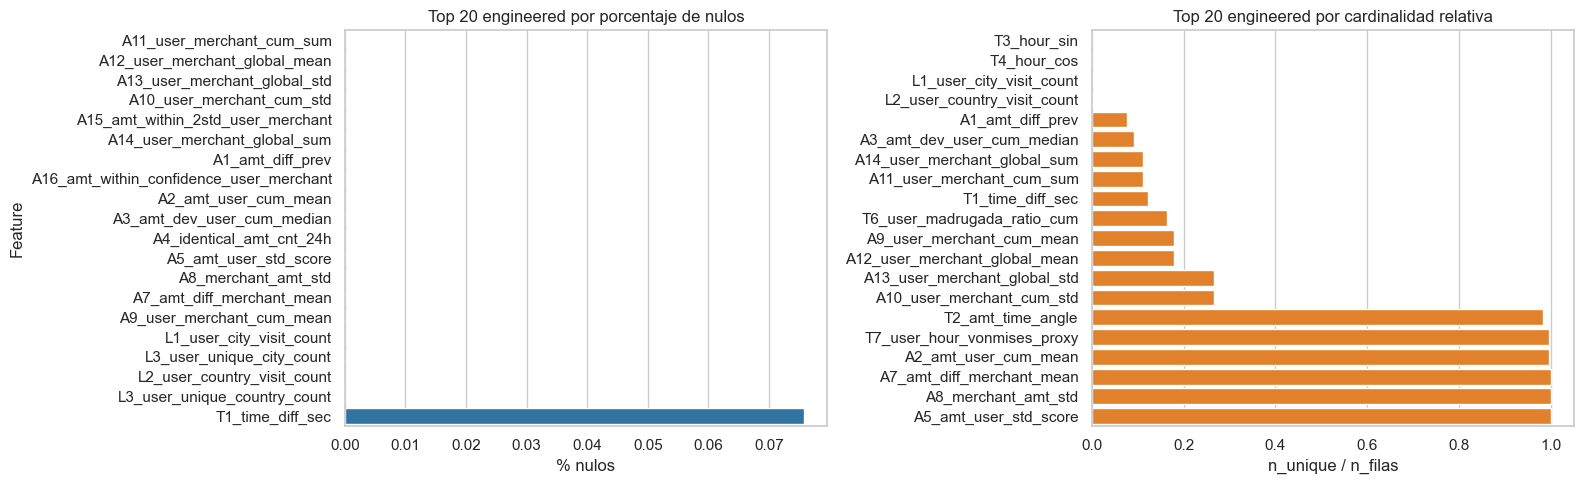

Resumen robusto de engineered numericas (muestra):


,mean,std,min,1%,5%,50%,95%,99%,max
A10_user_merchant_cum_std,17.697230,79.133669,0.000000,0.000000,0.000000,0.000000,76.681204,272.309248,"17,736.804870"
A11_user_merchant_cum_sum,106.170879,220.746932,0.000000,0.000000,0.000000,24.170000,430.133000,945.560000,"25,090.250000"
A12_user_merchant_global_mean,61.768597,100.671718,1.000000,1.990000,5.100000,47.520000,146.250000,325.700000,"25,086.940000"
A13_user_merchant_global_std,17.697230,79.133669,0.000000,0.000000,0.000000,0.000000,76.681204,272.309248,"17,736.804870"
A14_user_merchant_global_sum,106.170879,220.746932,0.000000,0.000000,0.000000,24.170000,430.133000,945.560000,"25,090.250000"
A15_amt_within_2std_user_merchant,0.286415,0.452086,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
A16_amt_within_confidence_user_merchant,0.134084,0.340742,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
A1_amt_diff_prev,75.420299,206.416076,0.000000,0.340000,1.930000,40.800000,220.860000,667.220000,"28,924.250000"
A2_amt_user_cum_mean,70.372300,21.075157,1.030000,42.584197,49.128641,65.032608,98.105197,112.950290,"1,433.540000"
A3_amt_dev_user_cum_median,52.065618,152.836385,0.000000,0.610000,3.060000,30.440000,147.815000,486.642600,"28,908.190000"


In [9]:
if len(engineered_cols) > 0:
    _, axes = plt.subplots(1, 2, figsize=(16, 5))

    top_null = (
        engineered_profile.sort_values("null_pct", ascending=False)
        .head(20)
        .sort_values("null_pct", ascending=True)
    )
    sns.barplot(data=top_null, x="null_pct", y="feature", ax=axes[0], color="#1f77b4")
    axes[0].set_title("Top 20 engineered por porcentaje de nulos")
    axes[0].set_xlabel("% nulos")
    axes[0].set_ylabel("Feature")

    top_card = (
        engineered_profile.sort_values("unique_ratio", ascending=False)
        .head(20)
        .sort_values("unique_ratio", ascending=True)
    )
    sns.barplot(data=top_card, x="unique_ratio", y="feature", ax=axes[1], color="#ff7f0e")
    axes[1].set_title("Top 20 engineered por cardinalidad relativa")
    axes[1].set_xlabel("n_unique / n_filas")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

    if len(num_eng_cols) > 0:
        robust_stats = (
            df[num_eng_cols]
            .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
            .T[["mean", "std", "min", "1%", "5%", "50%", "95%", "99%", "max"]]
        )
        print("Resumen robusto de engineered numericas (muestra):")
        display(robust_stats.head(25))

In [10]:
from sklearn.feature_selection import mutual_info_classif

if len(engineered_cols) > 0:
    y_full = df[TARGET_COL].astype(int)

    # Muestreo estratificado para acelerar MI en datasets grandes
    max_mi_rows = 200_000
    working_df = df[engineered_cols + [TARGET_COL]].copy()

    if len(working_df) > max_mi_rows:
        sampled, _ = train_test_split(
            working_df,
            train_size=max_mi_rows,
            stratify=working_df[TARGET_COL],
            random_state=RANDOM_STATE,
        )
        sampled = sampled.reset_index(drop=True)
    else:
        sampled = working_df.copy()

    y_sample = sampled[TARGET_COL].astype(int)

    corr_rows = []
    for col in engineered_cols:
        s = df[col]

        # Correlacion punto-biserial aproximada con target binario
        if pd.api.types.is_numeric_dtype(s):
            corr_val = s.corr(y_full)
            auc_val = np.nan
            try:
                valid = s.notna() & y_full.notna()
                if valid.sum() > 100 and y_full[valid].nunique() == 2:
                    score = s[valid]
                    auc_raw = roc_auc_score(y_full[valid], score)
                    auc_val = max(auc_raw, 1 - auc_raw)
            except Exception:
                auc_val = np.nan
        else:
            corr_val = np.nan
            auc_val = np.nan

        corr_rows.append({
            "feature": col,
            "corr_with_target": corr_val,
            "abs_corr_with_target": abs(corr_val) if pd.notna(corr_val) else np.nan,
            "single_feature_auc": auc_val,
        })

    corr_df = pd.DataFrame(corr_rows)

    # Preparar matriz para mutual information (tratando tipos mixtos)
    X_mi = sampled[engineered_cols].copy()
    discrete_mask = []
    for col in engineered_cols:
        if pd.api.types.is_numeric_dtype(X_mi[col]):
            X_mi[col] = pd.to_numeric(X_mi[col], errors="coerce")
            X_mi[col] = X_mi[col].fillna(X_mi[col].median())
            discrete_mask.append(False)
        else:
            X_mi[col] = X_mi[col].astype(str).fillna("MISSING")
            X_mi[col], _ = pd.factorize(X_mi[col])
            discrete_mask.append(True)

    mi = mutual_info_classif(
        X_mi,
        y_sample,
        discrete_features=discrete_mask,
        random_state=RANDOM_STATE,
    )

    mi_df = pd.DataFrame({"feature": engineered_cols, "mutual_info": mi})

    engineered_signal_df = (
        engineered_profile[["feature", "family", "dtype", "null_pct", "unique_ratio"]]
        .merge(corr_df, on="feature", how="left")
        .merge(mi_df, on="feature", how="left")
        .sort_values(["mutual_info", "abs_corr_with_target"], ascending=False)
    )

    print("Top engineered features por señal univariada:")
    display(engineered_signal_df.head(30))

    suspicious = engineered_signal_df[
        (engineered_signal_df["single_feature_auc"].fillna(0) >= 0.95)
        | (engineered_signal_df["mutual_info"].fillna(0) > 0.3)
    ]
    print("Posibles features a revisar por señal extremadamente alta (potencial leakage):")
    display(suspicious.head(20))

Top engineered features por señal univariada:


,feature,family,dtype,null_pct,unique_ratio,corr_with_target,abs_corr_with_target,single_feature_auc,mutual_info
12,A6_amt_within_1std_user,A,int64,0.000000,0.000002,-0.198273,0.198273,0.824239,0.068442
22,L5_same_location_as_prev,L,int64,0.000000,0.000002,-0.025600,0.025600,0.504644,0.053581
18,L3_user_unique_city_count,L,int64,0.000000,0.000002,-0.025600,0.025600,0.504644,0.053360
23,L6_location_seen_before,L,int64,0.000000,0.000002,-0.025600,0.025600,0.504644,0.053309
20,L4_user_city_txn_ratio,L,float64,0.000000,0.000002,-0.025600,0.025600,0.504644,0.052935
21,L4_user_country_txn_ratio,L,float64,0.000000,0.000002,-0.025600,0.025600,0.504644,0.052694
19,L3_user_unique_country_count,L,int64,0.000000,0.000002,-0.025600,0.025600,0.504644,0.052330
36,T9_time_interval_coherent,T,int64,0.000000,0.000002,-0.008334,0.008334,0.511364,0.050877
13,A7_amt_diff_merchant_mean,A,float64,0.000000,0.998859,0.209217,0.209217,0.892588,0.015790
9,A3_amt_dev_user_cum_median,A,float64,0.000000,0.091593,0.213041,0.213041,0.872553,0.014312


Posibles features a revisar por señal extremadamente alta (potencial leakage):


,feature,family,dtype,null_pct,unique_ratio,corr_with_target,abs_corr_with_target,single_feature_auc,mutual_info


## 3. Pipeline de preprocesamiento y entrenamiento (sin leakage)

Buenas practicas aplicadas:
- train/test split antes de cualquier ajuste de pipeline.
- Imputacion, encoding y SMOTENC dentro del pipeline (por fold en CV).
- Evaluacion de generalizacion en holdout no visto.
- Metricas enfocadas en alto desbalance (PR-AUC, Recall, F1, Balanced Accuracy, MCC).

Paso adicional de robustez de etiquetas en entrenamiento:
- Muestreo inteligente por embeddings DNN para identificar y remover no-fraudes potencialmente ruidosos cercanos a fraudes.

## 3.1 Split de entrenamiento y filtro inteligente (ejecutable)

El bloque de código siguiente crea `X_train_bench` y `y_train_bench` como dataset final para CV/holdout, aplicando:
- split estratificado train/test,
- submuestreo benchmark opcional,
- filtro inteligente de ruido por embeddings DNN (solo sobre train).

In [11]:
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

# Para hacer benchmarking reproducible y computacionalmente viable
BENCHMARK_MAX_TRAIN_ROWS = 300_000
if len(X_train) > BENCHMARK_MAX_TRAIN_ROWS:
    X_train_bench, _, y_train_bench, _ = train_test_split(
        X_train,
        y_train,
        train_size=BENCHMARK_MAX_TRAIN_ROWS,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )
    benchmark_sampling_note = (
        f"Benchmark train submuestreado estratificadamente a {len(X_train_bench):,} filas"
    )
else:
    X_train_bench, y_train_bench = X_train.copy(), y_train.copy()
    benchmark_sampling_note = "Benchmark train usa el 100% de train"

benchmark_sampling_note_before_filter = benchmark_sampling_note

# -----------------------------------------------------------------------------
# Muestreo Inteligente por Embeddings DNN (solo sobre train)
# -----------------------------------------------------------------------------
def _mlp_hidden_embedding(X_mat: np.ndarray, mlp: MLPClassifier) -> np.ndarray:
    h = X_mat
    for layer_idx in range(len(mlp.coefs_) - 1):
        h = h @ mlp.coefs_[layer_idx] + mlp.intercepts_[layer_idx]
        if mlp.activation == "relu":
            h = np.maximum(0, h)
        elif mlp.activation == "tanh":
            h = np.tanh(h)
        elif mlp.activation == "logistic":
            h = 1.0 / (1.0 + np.exp(-h))
        else:
            raise ValueError(f"Activacion no soportada: {mlp.activation}")
    return h


def smart_noise_filter_with_embeddings(
    X_in: pd.DataFrame,
    y_in: pd.Series,
    num_cols: list,
    cat_cols: list,
    k_neighbors: int = 5,
    drop_quantile: float = 0.015,
    max_fit_rows: int = 200_000,
    random_state: int = RANDOM_STATE,
):
    X_work = X_in.copy()
    y_work = y_in.copy().astype(int)

    # Submuestra para entrenar el DNN embedding sin costo excesivo
    if len(X_work) > max_fit_rows:
        X_fit, _, y_fit, _ = train_test_split(
            X_work,
            y_work,
            train_size=max_fit_rows,
            stratify=y_work,
            random_state=random_state,
        )
    else:
        X_fit, y_fit = X_work, y_work

    embed_preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                num_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "encoder",
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                                encoded_missing_value=-1,
                            ),
                        ),
                    ]
                ),
                cat_cols,
            ),
        ],
        remainder="drop",
    )

    X_fit_emb = embed_preprocessor.fit_transform(X_fit)
    X_all_emb = embed_preprocessor.transform(X_work)

    # DNN compacto para embedding latente
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=1024,
        learning_rate_init=1e-3,
        max_iter=25,
        early_stopping=True,
        n_iter_no_change=3,
        random_state=random_state,
    )
    mlp.fit(X_fit_emb, y_fit)

    emb_all = _mlp_hidden_embedding(np.asarray(X_all_emb), mlp)

    idx_major = np.where(y_work.values == 0)[0]
    idx_minor = np.where(y_work.values == 1)[0]

    if len(idx_minor) < 2:
        print("No se aplica filtro inteligente: minoria insuficiente.")
        return X_work, y_work, {
            "dropped_majority": 0,
            "dropped_pct_over_train": 0.0,
            "threshold": np.nan,
            "k_neighbors": 0,
        }

    k_eff = min(k_neighbors, len(idx_minor))

    nn = NearestNeighbors(n_neighbors=k_eff, metric="euclidean")
    nn.fit(emb_all[idx_minor])
    dists, _ = nn.kneighbors(emb_all[idx_major])

    mean_dist = dists.mean(axis=1)
    threshold = float(np.quantile(mean_dist, drop_quantile))

    # No-fraudes demasiado cercanos a fraudes => potencial ruido de etiqueta
    noisy_major_mask = mean_dist <= threshold
    drop_major_idx = idx_major[noisy_major_mask]

    keep_mask = np.ones(len(X_work), dtype=bool)
    keep_mask[drop_major_idx] = False

    X_clean = X_work.iloc[keep_mask].copy()
    y_clean = y_work.iloc[keep_mask].copy()

    summary = {
        "dropped_majority": int(len(drop_major_idx)),
        "dropped_pct_over_train": float(len(drop_major_idx) / len(X_work) * 100),
        "threshold": threshold,
        "k_neighbors": int(k_eff),
    }
    return X_clean, y_clean, summary


X_train_clean, y_train_clean, noise_filter_summary = smart_noise_filter_with_embeddings(
    X_in=X_train_bench,
    y_in=y_train_bench,
    num_cols=numeric_cols,
    cat_cols=categorical_cols,
    k_neighbors=5,
    drop_quantile=0.015,
    max_fit_rows=180_000,
)

# Dataset final de entrenamiento antes de CV/modelado
X_train_bench = X_train_clean
y_train_bench = y_train_clean

print("Resumen de split:")
print(f"Train completo: {X_train.shape} | Test: {X_test.shape}")
print(f"Train benchmark (antes de filtro): {benchmark_sampling_note_before_filter}")
print(f"Train final tras filtro inteligente: {X_train_bench.shape}")
print(f"Fraud rate train completo: {y_train.mean():.6f}")
print(f"Fraud rate train final:    {y_train_bench.mean():.6f}")
print(f"Fraud rate test:           {y_test.mean():.6f}")
print(f"Features numericas: {len(numeric_cols)}")
print(f"Features categoricas: {len(categorical_cols)}")
print("\nFiltro inteligente aplicado:")
print(noise_filter_summary)

Resumen de split:
Train completo: (1037340, 49) | Test: (259335, 49)
Train benchmark (antes de filtro): Benchmark train submuestreado estratificadamente a 300,000 filas
Train final tras filtro inteligente: (295526, 49)
Fraud rate train completo: 0.005789
Fraud rate train final:    0.005878
Fraud rate test:           0.005788
Features numericas: 43
Features categoricas: 6

Filtro inteligente aplicado:
{'dropped_majority': 4474, 'dropped_pct_over_train': 1.4913333333333334, 'threshold': 13.662756185721022, 'k_neighbors': 5}


In [12]:
# Todos los modelos actuales son de arboles, por lo que estandarizar no aporta señal y agrega costo.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                encoded_missing_value=-1,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop",
)

# SMOTENC respeta el tratamiento de variables categoricas en datasets mixtos.
categorical_feature_idx = list(range(len(numeric_cols), len(numeric_cols) + len(categorical_cols)))
smote = SMOTENC(
    categorical_features=categorical_feature_idx,
    random_state=RANDOM_STATE,
    k_neighbors=3,
    sampling_strategy=0.15,
)

MODEL_PARAMS = {
    "XGBoost": {
        "n_estimators": 320,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    },
    "RandomForest": {
        "n_estimators": 350,
        "min_samples_leaf": 3,
        "class_weight": "balanced_subsample",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    },
    "LightGBM": {
        "n_estimators": 380,
        "learning_rate": 0.05,
        "num_leaves": 63,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbose": -1,
    },
    "CatBoost": {
        "iterations": 350,
        "depth": 8,
        "learning_rate": 0.05,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "auto_class_weights": "Balanced",
        "random_seed": RANDOM_STATE,
        "verbose": False,
    },
}

ALL_MODEL_NAMES = list(MODEL_PARAMS.keys())

# 4 folds reduce costo frente a 5 sin perder demasiada estabilidad.
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)


def make_estimator(model_name, custom_params=None):
    if model_name not in MODEL_PARAMS:
        raise ValueError(f"Modelo no soportado: {model_name}. Disponibles: {ALL_MODEL_NAMES}")

    params = MODEL_PARAMS[model_name].copy()
    if custom_params:
        params.update(custom_params)

    if model_name == "XGBoost":
        return XGBClassifier(**params)
    if model_name == "RandomForest":
        return RandomForestClassifier(**params)
    if model_name == "LightGBM":
        return LGBMClassifier(**params)
    if model_name == "CatBoost":
        return CatBoostClassifier(**params)

    raise ValueError(f"Fabrica no implementada para {model_name}")


def build_pipeline_by_name(model_name, custom_params=None):
    model = make_estimator(model_name, custom_params=custom_params)
    return ImbPipeline(
        steps=[
            ("preprocess", preprocessor),
            ("smote", clone(smote)),
            ("model", model),
        ]
    )


print("Pipeline base y fabricas de modelos configuradas")
print(f"Modelos disponibles: {ALL_MODEL_NAMES}")

Pipeline base y fabricas de modelos configuradas
Modelos disponibles: ['XGBoost', 'RandomForest', 'LightGBM', 'CatBoost']


In [13]:
from sklearn.metrics import make_scorer

PRIMARY_METRIC_LABEL = "pr_auc"
PRIMARY_METRIC_SKLEARN = "average_precision"

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": PRIMARY_METRIC_SKLEARN,
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "balanced_acc": "balanced_accuracy",
    "mcc": make_scorer(matthews_corrcoef),
}


def run_cv_for_model(model_name, X_in, y_in, custom_params=None):
    print(f"\n[CV] Entrenando {model_name}...")

    pipe = build_pipeline_by_name(model_name, custom_params=custom_params)

    wall_start = time.perf_counter()
    cv_result = cross_validate(
        pipe,
        X_in,
        y_in,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )
    wall_seconds = time.perf_counter() - wall_start

    return {
        "model": model_name,
        "cv_rows": len(X_in),
        "cv_wall_time_sec": wall_seconds,
        "cv_fit_time_mean_sec": np.mean(cv_result["fit_time"]),
        "cv_score_time_mean_sec": np.mean(cv_result["score_time"]),
        "roc_auc_mean": np.mean(cv_result["test_roc_auc"]),
        "roc_auc_std": np.std(cv_result["test_roc_auc"]),
        "pr_auc_mean": np.mean(cv_result["test_pr_auc"]),
        "pr_auc_std": np.std(cv_result["test_pr_auc"]),
        "f1_mean": np.mean(cv_result["test_f1"]),
        "recall_mean": np.mean(cv_result["test_recall"]),
        "precision_mean": np.mean(cv_result["test_precision"]),
        "balanced_acc_mean": np.mean(cv_result["test_balanced_acc"]),
        "mcc_mean": np.mean(cv_result["test_mcc"]),
        "notes": f"primary_metric={PRIMARY_METRIC_LABEL}",
    }


def run_cv_benchmark(model_names, X_in, y_in, custom_params_map=None):
    rows = []
    custom_params_map = custom_params_map or {}

    for model_name in model_names:
        custom_params = custom_params_map.get(model_name)
        row = run_cv_for_model(
            model_name=model_name,
            X_in=X_in,
            y_in=y_in,
            custom_params=custom_params,
        )
        rows.append(row)

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values("pr_auc_mean", ascending=False).reset_index(drop=True)


[CV] Entrenando XGBoost...

[CV] Entrenando RandomForest...

[CV] Entrenando LightGBM...

[CV] Entrenando CatBoost...

Resultados de Cross-Validation (ordenado por PR-AUC):


,model,cv_rows,cv_wall_time_sec,cv_fit_time_mean_sec,cv_score_time_mean_sec,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,recall_mean,precision_mean,balanced_acc_mean,mcc_mean,notes
0,LightGBM,295526,46.722263,11.112907,0.549689,0.997981,0.000726,0.943274,0.006610,0.892548,0.870471,0.915864,0.934999,0.892242,primary_metric=pr_auc
1,CatBoost,295526,66.618138,16.383182,0.252700,0.996612,0.001148,0.922502,0.012413,0.826250,0.899254,0.764286,0.948807,0.827926,primary_metric=pr_auc
2,XGBoost,295526,42.498108,10.221761,0.382116,0.996701,0.001126,0.922153,0.009268,0.868297,0.833042,0.906800,0.916267,0.868371,primary_metric=pr_auc
3,RandomForest,295526,107.926456,26.256988,0.701545,0.992985,0.001505,0.842213,0.011877,0.774417,0.776626,0.772310,0.887636,0.773105,primary_metric=pr_auc


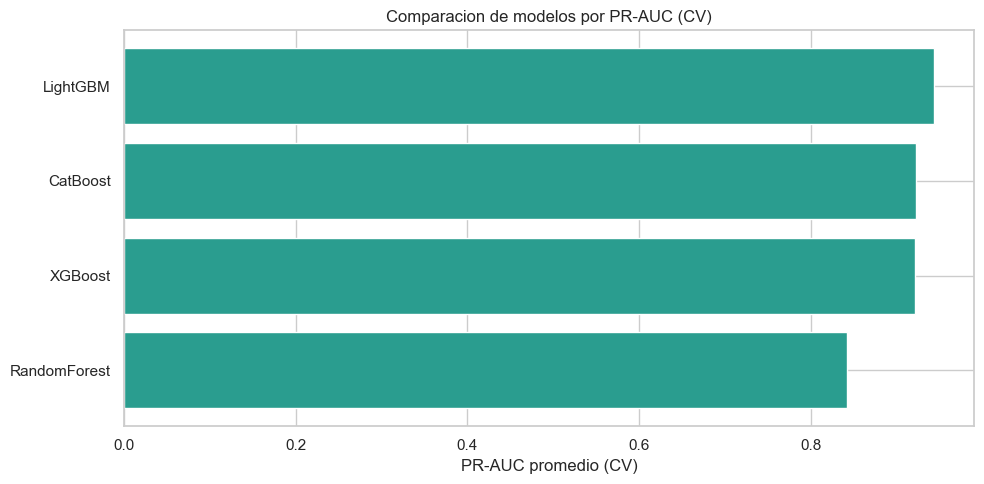

In [14]:
# Puedes correr uno solo o varios modelos sin depender de los demas.
MODELS_TO_RUN_CV = ["XGBoost", "RandomForest", "LightGBM", "CatBoost"]
CUSTOM_CV_PARAMS = {
    # Ejemplo: "XGBoost": {"max_depth": 8, "n_estimators": 450}
}

benchmark_cv_df = run_cv_benchmark(
    model_names=MODELS_TO_RUN_CV,
    X_in=X_train_bench,
    y_in=y_train_bench,
    custom_params_map=CUSTOM_CV_PARAMS,
)

if benchmark_cv_df.empty:
    print("No se ejecutaron modelos en CV. Revisa MODELS_TO_RUN_CV.")
else:
    print("\nResultados de Cross-Validation (ordenado por PR-AUC):")
    display(benchmark_cv_df)

    plt.figure(figsize=(10, 5))
    plot_df = benchmark_cv_df.sort_values("pr_auc_mean", ascending=True)
    plt.barh(plot_df["model"], plot_df["pr_auc_mean"], color="#2a9d8f")
    plt.xlabel("PR-AUC promedio (CV)")
    plt.title("Comparacion de modelos por PR-AUC (CV)")
    plt.tight_layout()
    plt.show()

## 4. Funcion de test y evaluacion en holdout

La funcion `test_model_results` entrega:
- Tiempos (`fit` e inferencia).
- Metricas principales para alto desbalance.
- Matriz de confusion.
- Curva ROC y curva Precision-Recall.
- Lift por deciles y `precision@k` / `recall@k`.

In [15]:
def _scores_from_estimator(estimator, X_eval):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_eval)[:, 1]

    if hasattr(estimator, "decision_function"):
        raw = estimator.decision_function(X_eval)
        raw = np.asarray(raw, dtype=float)
        min_v, max_v = np.min(raw), np.max(raw)
        if max_v - min_v < 1e-12:
            return np.zeros_like(raw)
        return (raw - min_v) / (max_v - min_v)

    raise ValueError("El estimador no soporta predict_proba ni decision_function")


def _precision_recall_at_k(y_true, y_score, k_frac=0.01):
    n = len(y_true)
    k = max(1, int(n * k_frac))
    order = np.argsort(-y_score)
    top_idx = order[:k]
    y_top = y_true.iloc[top_idx] if isinstance(y_true, pd.Series) else y_true[top_idx]

    precision_k = float(np.mean(y_top))
    total_positives = float(np.sum(y_true))
    recall_k = float(np.sum(y_top) / total_positives) if total_positives > 0 else 0.0

    return precision_k, recall_k, k


def _lift_table(y_true, y_score, n_bins=10):
    tmp = pd.DataFrame({"y_true": y_true, "y_score": y_score}).sort_values("y_score", ascending=False)
    tmp["decile"] = pd.qcut(np.arange(len(tmp)), q=n_bins, labels=False, duplicates="drop") + 1

    out = (
        tmp.groupby("decile")
        .agg(n=("y_true", "size"), fraud_rate=("y_true", "mean"), fraud_count=("y_true", "sum"))
        .reset_index()
        .sort_values("decile")
    )
    base_rate = tmp["y_true"].mean()
    out["lift"] = out["fraud_rate"] / base_rate
    return out


def test_model_results(
    model_name,
    pipeline,
    X_train_in,
    y_train_in,
    X_test_in,
    y_test_in,
    threshold=0.5,
    show_plots=True,
):
    X_fit, y_fit = X_train_in, y_train_in

    fit_start = time.perf_counter()
    pipeline.fit(X_fit, y_fit)
    fit_time_sec = time.perf_counter() - fit_start

    score_start = time.perf_counter()
    y_score = _scores_from_estimator(pipeline, X_test_in)
    score_time_sec = time.perf_counter() - score_start

    y_pred = (y_score >= threshold).astype(int)

    metrics = {
        "model": model_name,
        "fit_rows": len(X_fit),
        "fit_time_sec": fit_time_sec,
        "score_time_sec": score_time_sec,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_test_in, y_score),
        "pr_auc": average_precision_score(y_test_in, y_score),
        "f1": f1_score(y_test_in, y_pred, zero_division=0),
        "recall": recall_score(y_test_in, y_pred, zero_division=0),
        "precision": precision_score(y_test_in, y_pred, zero_division=0),
        "balanced_acc": balanced_accuracy_score(y_test_in, y_pred),
        "mcc": matthews_corrcoef(y_test_in, y_pred),
        "notes": "",
    }

    cm = confusion_matrix(y_test_in, y_pred)

    pr_k_rows = []
    for k_frac in [0.01, 0.02, 0.05, 0.10]:
        p_k, r_k, k_abs = _precision_recall_at_k(y_test_in, y_score, k_frac=k_frac)
        pr_k_rows.append({
            "k_frac": k_frac,
            "k_abs": k_abs,
            "precision_at_k": p_k,
            "recall_at_k": r_k,
        })
    pr_at_k_df = pd.DataFrame(pr_k_rows)

    lift_df = _lift_table(y_test_in, y_score, n_bins=10)

    if show_plots:
        fpr, tpr, _ = roc_curve(y_test_in, y_score)
        prc_precision, prc_recall, _ = precision_recall_curve(y_test_in, y_score)

        _, axes = plt.subplots(1, 3, figsize=(20, 5))

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
        axes[0].set_title(f"{model_name} - Matriz de confusion")
        axes[0].set_xlabel("Prediccion")
        axes[0].set_ylabel("Real")

        axes[1].plot(fpr, tpr, label=f"AUC={metrics['roc_auc']:.4f}", color="#e76f51")
        axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
        axes[1].set_title(f"{model_name} - Curva ROC")
        axes[1].set_xlabel("FPR")
        axes[1].set_ylabel("TPR")
        axes[1].legend(loc="lower right")

        baseline = y_test_in.mean()
        axes[2].plot(prc_recall, prc_precision, label=f"PR-AUC={metrics['pr_auc']:.4f}", color="#2a9d8f")
        axes[2].hlines(baseline, 0, 1, linestyles="--", colors="gray", label=f"Base rate={baseline:.4f}")
        axes[2].set_title(f"{model_name} - Curva Precision-Recall")
        axes[2].set_xlabel("Recall")
        axes[2].set_ylabel("Precision")
        axes[2].legend(loc="upper right")

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(9, 4))
        sns.barplot(data=lift_df, x="decile", y="lift", color="#264653")
        plt.axhline(1.0, linestyle="--", color="gray")
        plt.title(f"{model_name} - Lift por deciles")
        plt.xlabel("Decil (1 = mayor score)")
        plt.ylabel("Lift")
        plt.tight_layout()
        plt.show()

        print(f"Precision@k / Recall@k - {model_name}")
        display(pr_at_k_df)

    return {
        "fitted_pipeline": pipeline,
        "metrics": metrics,
        "confusion_matrix": cm,
        "y_score": y_score,
        "pr_at_k": pr_at_k_df,
        "lift": lift_df,
    }

Datos de entrenamiento usados para benchmark holdout: (295526, 49)
Benchmark train submuestreado estratificadamente a 300,000 filas

[HOLDOUT] Evaluando XGBoost...

[HOLDOUT] Evaluando RandomForest...

[HOLDOUT] Evaluando LightGBM...

[HOLDOUT] Evaluando CatBoost...

Resumen holdout (ordenado por PR-AUC):


,model,fit_rows,fit_time_sec,score_time_sec,threshold,roc_auc,pr_auc,f1,recall,precision,balanced_acc,mcc,notes
0,LightGBM,295526,16.871307,0.814005,0.500000,0.998398,0.950302,0.901399,0.901399,0.901399,0.950413,0.900825,
1,CatBoost,295526,30.116478,0.388034,0.500000,0.997457,0.930472,0.815672,0.915390,0.735546,0.956737,0.819421,
2,XGBoost,295526,13.268767,0.393726,0.500000,0.997587,0.929929,0.869417,0.849434,0.890363,0.924412,0.868918,
3,RandomForest,295526,35.779998,0.894563,0.500000,0.994174,0.859711,0.781901,0.800133,0.764481,0.899349,0.780807,



Generando graficas completas solo para el mejor modelo: LightGBM


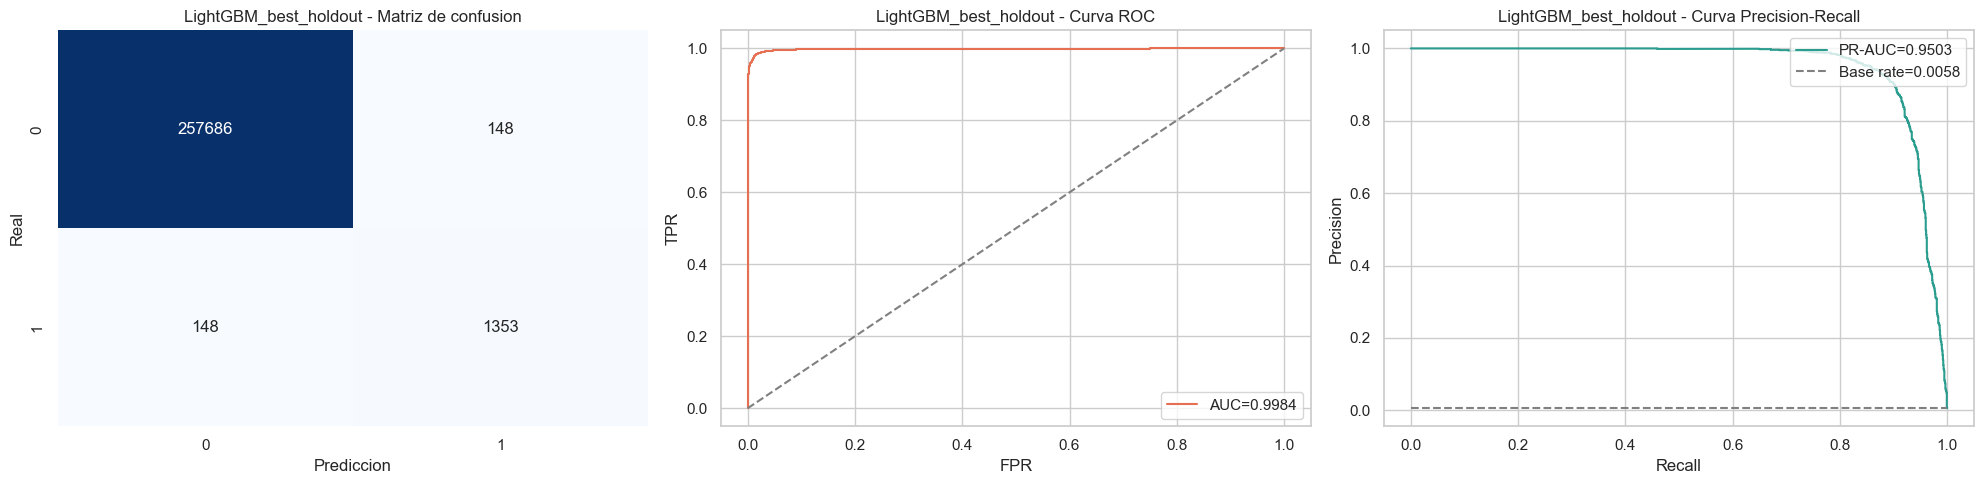

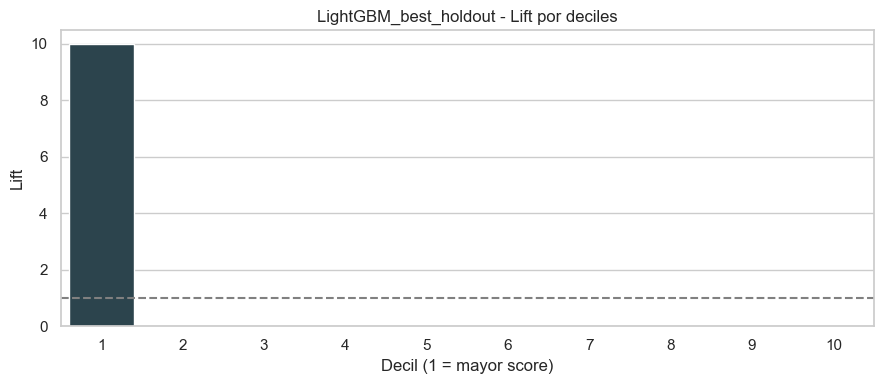

Precision@k / Recall@k - LightGBM_best_holdout


,k_frac,k_abs,precision_at_k,recall_at_k
0,0.010000,2593,0.553799,0.956696
1,0.020000,5186,0.283841,0.980680
2,0.050000,12966,0.114993,0.993338
3,0.100000,25933,0.057726,0.997335


In [16]:
holdout_results = {}
holdout_rows = []

MODELS_TO_RUN_HOLDOUT = MODELS_TO_RUN_CV.copy() if "MODELS_TO_RUN_CV" in globals() else ALL_MODEL_NAMES.copy()
CUSTOM_HOLDOUT_PARAMS = {
    # Ejemplo: "LightGBM": {"num_leaves": 95, "learning_rate": 0.03}
}

print(f"Datos de entrenamiento usados para benchmark holdout: {X_train_bench.shape}")
if "benchmark_sampling_note_before_filter" in globals():
    print(benchmark_sampling_note_before_filter)

for model_name in MODELS_TO_RUN_HOLDOUT:
    print(f"\n[HOLDOUT] Evaluando {model_name}...")
    pipe = build_pipeline_by_name(
        model_name,
        custom_params=CUSTOM_HOLDOUT_PARAMS.get(model_name),
    )

    # Evaluacion rapida para todos los modelos: solo metricas (sin graficas)
    result = test_model_results(
        model_name=model_name,
        pipeline=pipe,
        X_train_in=X_train_bench,
        y_train_in=y_train_bench,
        X_test_in=X_test,
        y_test_in=y_test,
        threshold=0.5,
        show_plots=False,
    )

    holdout_results[model_name] = result
    holdout_rows.append(result["metrics"])

if len(holdout_rows) == 0:
    raise ValueError("No se evaluo ningun modelo en holdout. Revisa MODELS_TO_RUN_HOLDOUT.")

holdout_summary_df = pd.DataFrame(holdout_rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("\nResumen holdout (ordenado por PR-AUC):")
display(holdout_summary_df)

best_model_name = holdout_summary_df.iloc[0]["model"]
print(f"\nGenerando graficas completas solo para el mejor modelo: {best_model_name}")

_ = test_model_results(
    model_name=f"{best_model_name}_best_holdout",
    pipeline=build_pipeline_by_name(
        best_model_name,
        custom_params=CUSTOM_HOLDOUT_PARAMS.get(best_model_name),
    ),
    X_train_in=X_train_bench,
    y_train_in=y_train_bench,
    X_test_in=X_test,
    y_test_in=y_test,
    threshold=0.5,
    show_plots=True,
)

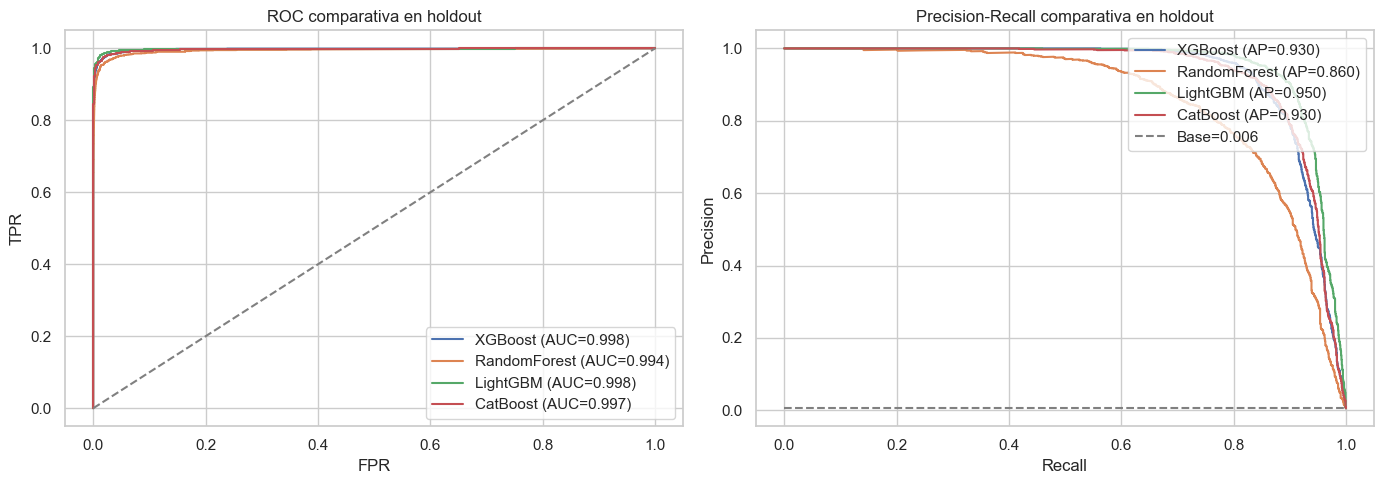

Mejor modelo por PR-AUC en holdout: LightGBM


In [17]:
# Comparativa visual conjunta ROC y PR
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for model_name, result in holdout_results.items():
    y_score = result["y_score"]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_val = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_val:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC comparativa en holdout")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend(loc="lower right")

plt.subplot(1, 2, 2)
base_rate = y_test.mean()
for model_name, result in holdout_results.items():
    y_score = result["y_score"]
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, label=f"{model_name} (AP={ap:.3f})")
plt.hlines(base_rate, 0, 1, linestyles="--", colors="gray", label=f"Base={base_rate:.3f}")
plt.title("Precision-Recall comparativa en holdout")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

best_model_name = holdout_summary_df.iloc[0]["model"]
print(f"Mejor modelo por PR-AUC en holdout: {best_model_name}")

## 5. Revision tecnica y tuning ligero (enfocado en PR-AUC)

Mejoras aplicadas en esta version:
- Se prioriza **PR-AUC** como metrica principal para el caso altamente desbalanceado.
- Se reduce costo de sobremuestreo con `SMOTENC(sampling_strategy=0.15)` para datos mixtos.
- Se usa una configuracion de CV mas eficiente para iterar mas rapido.
- Se incorpora una busqueda de hiperparametros acotada para no exceder tiempos.

Criterio de tuning:
- Seleccionar 2 modelos candidatos (segun CV baseline si ya existe).
- `RandomizedSearchCV` ligero con perfil configurable (`quick` o `balanced`).
- Ranking final por PR-AUC en holdout.

In [18]:
if "benchmark_cv_df" in globals() and not benchmark_cv_df.empty:
    tech_review_df = benchmark_cv_df.copy()
    tech_review_df["cv_time_min"] = tech_review_df["cv_wall_time_sec"] / 60
    tech_review_df["pr_auc_per_min"] = tech_review_df["pr_auc_mean"] / tech_review_df["cv_time_min"].replace(0, np.nan)

    print("Revision tecnica de baseline (trade-off calidad vs tiempo):")
    display(
        tech_review_df[
            [
                "model",
                "pr_auc_mean",
                "pr_auc_std",
                "roc_auc_mean",
                "recall_mean",
                "precision_mean",
                "cv_time_min",
                "pr_auc_per_min",
            ]
        ].sort_values(["pr_auc_mean", "pr_auc_per_min"], ascending=False)
    )

    bottleneck_df = tech_review_df.sort_values("cv_wall_time_sec", ascending=False)
    print("Modelos mas costosos por tiempo total de CV:")
    display(bottleneck_df[["model", "cv_wall_time_sec", "cv_fit_time_mean_sec"]].head(4))
else:
    print("Aun no existe benchmark_cv_df. Ejecuta la celda de benchmark baseline para habilitar la revision cuantitativa.")

Revision tecnica de baseline (trade-off calidad vs tiempo):


,model,pr_auc_mean,pr_auc_std,roc_auc_mean,recall_mean,precision_mean,cv_time_min,pr_auc_per_min
0,LightGBM,0.943274,0.006610,0.997981,0.870471,0.915864,0.778704,1.211337
1,CatBoost,0.922502,0.012413,0.996612,0.899254,0.764286,1.110302,0.830856
2,XGBoost,0.922153,0.009268,0.996701,0.833042,0.906800,0.708302,1.301921
3,RandomForest,0.842213,0.011877,0.992985,0.776626,0.772310,1.798774,0.468215


Modelos mas costosos por tiempo total de CV:


,model,cv_wall_time_sec,cv_fit_time_mean_sec
3,RandomForest,107.926456,26.256988
1,CatBoost,66.618138,16.383182
0,LightGBM,46.722263,11.112907
2,XGBoost,42.498108,10.221761


In [19]:
from sklearn.model_selection import RandomizedSearchCV


def _stratified_subsample(X_in, y_in, max_rows, seed=RANDOM_STATE):
    if len(X_in) <= max_rows:
        return X_in, y_in

    X_sub, _, y_sub, _ = train_test_split(
        X_in,
        y_in,
        train_size=max_rows,
        stratify=y_in,
        random_state=seed,
    )
    return X_sub, y_sub


TUNING_PROFILE = "quick"  # quick | balanced
MODELS_TO_TUNE = ["LightGBM", "XGBoost"]

if TUNING_PROFILE == "quick":
    TUNING_MAX_ROWS = 80_000
    N_ITER_PER_MODEL = 4
    TUNING_CV_SPLITS = 2
else:
    TUNING_MAX_ROWS = 120_000
    N_ITER_PER_MODEL = 8
    TUNING_CV_SPLITS = 3

X_tune, y_tune = _stratified_subsample(X_train_bench, y_train_bench, max_rows=TUNING_MAX_ROWS)
print(f"Perfil tuning: {TUNING_PROFILE}")
print(f"Dataset para tuning: {X_tune.shape} | fraude={y_tune.mean():.6f}")

valid_models_to_tune = [m for m in MODELS_TO_TUNE if m in ALL_MODEL_NAMES]
print(f"Modelos candidatos para tuning ligero: {valid_models_to_tune}")

param_spaces = {
    "XGBoost": {
        "model__n_estimators": [220, 320, 420, 520],
        "model__max_depth": [4, 6, 8],
        "model__learning_rate": [0.03, 0.05, 0.08],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__min_child_weight": [1, 5, 10],
        "model__reg_lambda": [1, 5, 10],
    },
    "LightGBM": {
        "model__n_estimators": [220, 320, 420, 520],
        "model__learning_rate": [0.03, 0.05, 0.08],
        "model__num_leaves": [31, 47, 63, 95],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__min_child_samples": [20, 40, 80],
        "model__reg_lambda": [0, 1, 5, 10],
    },
    "RandomForest": {
        "model__n_estimators": [250, 350, 500],
        "model__max_depth": [None, 12, 20],
        "model__min_samples_leaf": [1, 2, 4],
        "model__min_samples_split": [2, 5, 10],
        "model__max_features": ["sqrt", 0.5, None],
    },
    "CatBoost": {
        "model__iterations": [220, 320, 420],
        "model__depth": [6, 8, 10],
        "model__learning_rate": [0.03, 0.05, 0.08],
        "model__l2_leaf_reg": [3, 5, 9],
        "model__bagging_temperature": [0, 1, 3],
    },
}

CUSTOM_TUNING_BASE_PARAMS = {
    # Ejemplo: "XGBoost": {"max_depth": 8, "n_estimators": 380}
}


def run_light_tuning(
    model_name,
    X_in,
    y_in,
    n_iter=N_ITER_PER_MODEL,
    custom_base_params_map=None,
):
    if model_name not in param_spaces:
        raise ValueError(f"No hay espacio de hiperparametros definido para {model_name}")

    custom_base_params_map = custom_base_params_map or {}
    base_custom = custom_base_params_map.get(model_name)

    estimator = build_pipeline_by_name(
        model_name=model_name,
        custom_params=base_custom,
    )
    tune_cv = StratifiedKFold(n_splits=TUNING_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_spaces[model_name],
        n_iter=n_iter,
        scoring=PRIMARY_METRIC_SKLEARN,
        n_jobs=1,
        cv=tune_cv,
        random_state=RANDOM_STATE,
        verbose=1,
        refit=True,
        return_train_score=False,
    )

    t0 = time.perf_counter()
    search.fit(X_in, y_in)
    elapsed = time.perf_counter() - t0

    return {
        "model": model_name,
        "search": search,
        "best_estimator": search.best_estimator_,
        "best_params": search.best_params_,
        "best_cv_pr_auc": search.best_score_,
        "tuning_time_sec": elapsed,
        "n_iter": n_iter,
    }


tuning_runs = []
for model_name in valid_models_to_tune:
    print(f"\n[TUNING] {model_name} | n_iter={N_ITER_PER_MODEL} | metric={PRIMARY_METRIC_LABEL}")
    result = run_light_tuning(
        model_name=model_name,
        X_in=X_tune,
        y_in=y_tune,
        custom_base_params_map=CUSTOM_TUNING_BASE_PARAMS,
    )
    tuning_runs.append(result)

if len(tuning_runs) == 0:
    print("No se ejecuto tuning. Revisa MODELS_TO_TUNE.")
    tuned_models = {}
    best_params_by_model = {}
else:
    tuning_summary_df = pd.DataFrame(
        [
            {
                "model": r["model"],
                "best_cv_pr_auc": r["best_cv_pr_auc"],
                "tuning_time_min": r["tuning_time_sec"] / 60,
                "n_iter": r["n_iter"],
                "cv_splits": TUNING_CV_SPLITS,
                "tuning_profile": TUNING_PROFILE,
            }
            for r in tuning_runs
        ]
    ).sort_values("best_cv_pr_auc", ascending=False)

    print("Resumen tuning ligero (ordenado por best_cv_pr_auc):")
    display(tuning_summary_df)

    tuned_models = {r["model"]: r["best_estimator"] for r in tuning_runs}
    best_params_by_model = {r["model"]: r["best_params"] for r in tuning_runs}

    print("Mejores hiperparametros encontrados:")
    for model_name, params in best_params_by_model.items():
        print(f"\n{model_name} -> {params}")

Perfil tuning: quick
Dataset para tuning: (80000, 49) | fraude=0.005875
Modelos candidatos para tuning ligero: ['LightGBM', 'XGBoost']

[TUNING] LightGBM | n_iter=4 | metric=pr_auc
Fitting 2 folds for each of 4 candidates, totalling 8 fits

[TUNING] XGBoost | n_iter=4 | metric=pr_auc
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Resumen tuning ligero (ordenado por best_cv_pr_auc):


,model,best_cv_pr_auc,tuning_time_min,n_iter,cv_splits,tuning_profile
0,LightGBM,0.877897,0.434733,4,2,quick
1,XGBoost,0.872659,0.408491,4,2,quick


Mejores hiperparametros encontrados:

LightGBM -> {'model__subsample': 1.0, 'model__reg_lambda': 5, 'model__num_leaves': 47, 'model__n_estimators': 220, 'model__min_child_samples': 40, 'model__learning_rate': 0.08, 'model__colsample_bytree': 0.8}

XGBoost -> {'model__subsample': 1.0, 'model__reg_lambda': 5, 'model__n_estimators': 520, 'model__min_child_weight': 10, 'model__max_depth': 6, 'model__learning_rate': 0.08, 'model__colsample_bytree': 0.6}


In [20]:
if "tuned_models" not in globals() or len(tuned_models) == 0:
    print("No hay modelos tuneados disponibles. Ejecuta primero la celda de tuning.")
else:
    tuned_holdout_results = {}
    tuned_holdout_rows = []

    for model_name, tuned_pipeline in tuned_models.items():
        print(f"\n[HOLDOUT - TUNED] Evaluando {model_name}...")
        result = test_model_results(
            model_name=f"{model_name}_tuned",
            pipeline=tuned_pipeline,
            X_train_in=X_train_bench,
            y_train_in=y_train_bench,
            X_test_in=X_test,
            y_test_in=y_test,
            threshold=0.5,
            show_plots=False,
        )
        tuned_holdout_results[model_name] = result
        tuned_holdout_rows.append(result["metrics"])

    tuned_holdout_summary_df = (
        pd.DataFrame(tuned_holdout_rows)
        .sort_values(["pr_auc", "recall"], ascending=False)
        .reset_index(drop=True)
    )

    print("Resumen holdout de modelos tuneados (prioridad PR-AUC):")
    display(tuned_holdout_summary_df)

    if "holdout_summary_df" in globals() and not holdout_summary_df.empty:
        baseline_comp = holdout_summary_df[["model", "pr_auc", "recall", "precision", "fit_time_sec"]].copy()
        baseline_comp["version"] = "baseline"

        tuned_comp = tuned_holdout_summary_df[["model", "pr_auc", "recall", "precision", "fit_time_sec"]].copy()
        tuned_comp["version"] = "tuned"

        print("Comparativo baseline vs tuned en holdout:")
        display(pd.concat([baseline_comp, tuned_comp], axis=0, ignore_index=True).sort_values(["pr_auc", "recall"], ascending=False))


[HOLDOUT - TUNED] Evaluando LightGBM...

[HOLDOUT - TUNED] Evaluando XGBoost...
Resumen holdout de modelos tuneados (prioridad PR-AUC):


,model,fit_rows,fit_time_sec,score_time_sec,threshold,roc_auc,pr_auc,f1,recall,precision,balanced_acc,mcc,notes
0,LightGBM_tuned,295526,12.917260,0.541812,0.500000,0.998421,0.947363,0.876800,0.912725,0.843596,0.955870,0.876742,
1,XGBoost_tuned,295526,14.546191,0.437042,0.500000,0.998616,0.945803,0.897735,0.871419,0.925690,0.935506,0.897572,


Comparativo baseline vs tuned en holdout:


,model,pr_auc,recall,precision,fit_time_sec,version
0,LightGBM,0.950302,0.901399,0.901399,16.871307,baseline
4,LightGBM_tuned,0.947363,0.912725,0.843596,12.917260,tuned
5,XGBoost_tuned,0.945803,0.871419,0.925690,14.546191,tuned
1,CatBoost,0.930472,0.915390,0.735546,30.116478,baseline
2,XGBoost,0.929929,0.849434,0.890363,13.268767,baseline
3,RandomForest,0.859711,0.800133,0.764481,35.779998,baseline


In [ ]:
# Diagnostico rapido de confiabilidad de resultados
summary_cols_cv = [
    "model", "pr_auc_mean", "pr_auc_std", "roc_auc_mean", "recall_mean", "precision_mean", "cv_wall_time_sec"
]
summary_cols_holdout = ["model", "pr_auc", "roc_auc", "recall", "precision", "f1", "mcc", "fit_time_sec"]

print("=== CV baseline ===")
display(benchmark_cv_df[summary_cols_cv].sort_values("pr_auc_mean", ascending=False))

print("=== Holdout baseline ===")
display(holdout_summary_df[summary_cols_holdout].sort_values("pr_auc", ascending=False))

if "tuned_holdout_summary_df" in globals() and not tuned_holdout_summary_df.empty:
    print("=== Holdout tuned ===")
    display(tuned_holdout_summary_df[summary_cols_holdout].sort_values("pr_auc", ascending=False))

    cv_top = benchmark_cv_df.sort_values("pr_auc_mean", ascending=False)[["model", "pr_auc_mean", "pr_auc_std"]].copy()
    hold_top = holdout_summary_df[["model", "pr_auc"]].copy().rename(columns={"pr_auc": "holdout_pr_auc"})
    tuned_top = tuned_holdout_summary_df[["model", "pr_auc"]].copy().rename(columns={"pr_auc": "tuned_holdout_pr_auc"})

    compare = cv_top.merge(hold_top, on="model", how="left").merge(tuned_top, on="model", how="left")
    compare["delta_holdout_vs_cv"] = compare["holdout_pr_auc"] - compare["pr_auc_mean"]
    compare["delta_tuned_vs_holdout"] = compare["tuned_holdout_pr_auc"] - compare["holdout_pr_auc"]

    print("=== Consistencia CV vs Holdout ===")
    display(compare.sort_values("pr_auc_mean", ascending=False))
else:
    print("No hay resultados tuned_holdout_summary_df para comparar.")

=== CV baseline ===


,model,pr_auc_mean,pr_auc_std,roc_auc_mean,recall_mean,precision_mean,cv_wall_time_sec
0,LightGBM,0.943274,0.006610,0.997981,0.870471,0.915864,46.722263
1,CatBoost,0.922502,0.012413,0.996612,0.899254,0.764286,66.618138
2,XGBoost,0.922153,0.009268,0.996701,0.833042,0.906800,42.498108
3,RandomForest,0.842213,0.011877,0.992985,0.776626,0.772310,107.926456


=== Holdout baseline ===


,model,pr_auc,roc_auc,recall,precision,f1,mcc,fit_time_sec
0,LightGBM,0.950302,0.998398,0.901399,0.901399,0.901399,0.900825,16.871307
1,CatBoost,0.930472,0.997457,0.915390,0.735546,0.815672,0.819421,30.116478
2,XGBoost,0.929929,0.997587,0.849434,0.890363,0.869417,0.868918,13.268767
3,RandomForest,0.859711,0.994174,0.800133,0.764481,0.781901,0.780807,35.779998


=== Holdout tuned ===


,model,pr_auc,roc_auc,recall,precision,f1,mcc,fit_time_sec
0,LightGBM_tuned,0.947363,0.998421,0.912725,0.843596,0.876800,0.876742,12.917260
1,XGBoost_tuned,0.945803,0.998616,0.871419,0.925690,0.897735,0.897572,14.546191


=== Consistencia CV vs Holdout ===


,model,pr_auc_mean,pr_auc_std,holdout_pr_auc,tuned_holdout_pr_auc,delta_holdout_vs_cv,delta_tuned_vs_holdout
0,LightGBM,0.943274,0.006610,0.950302,NaN,0.007028,NaN
1,CatBoost,0.922502,0.012413,0.930472,NaN,0.007970,NaN
2,XGBoost,0.922153,0.009268,0.929929,NaN,0.007776,NaN
3,RandomForest,0.842213,0.011877,0.859711,NaN,0.017498,NaN


: 